## import pandas as pd

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Read  Dataset

In [3]:
df = pd.read_csv('/content/Messy.csv')

## First 5 Rows

In [4]:
df.head(5)

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND23033,Benjamin Price,75.0,26209.0,03-01-2020,Jeremy Vasquez,American,Registered Nurse,Mid,Jade,...,822783.56,159454.18,282233.90,39104.34,577920.26,NaN,1.0,3.0,1.0,16.0
1,IND65845,Norma Austin,24.0,NaN,01-01-1999,NaN,African,Administrative Officer,High,Silver,...,147575.13,105053.48,139270.90,30227.92,865724.13,0.0,NaN,2.0,2.0,9.0
2,IND37063,Jesse Dunn,71.0,NaN,12-03-2015,Shawn Wallace,Australian,Safety Technician III,Mid,Jade,...,834989.69,767287.82,256364.40,NaN,1541737.47,0.0,4.0,4.0,2.0,8.0
3,IND79483,Terry Stewart,25.0,164.0,16-02-2012,Nicholas Cunningham,European,Senior Financial Analyst,Low,Jade,...,118972.18,NaN,55228.14,49267.40,545432.68,3.0,2.0,3.0,1.0,1.0
4,NaN,NaN,38.0,23225.0,25-08-2003,Victor Ramos,European,Web Developer III,High,Silver,...,32052.30,19231.38,40997.80,15670.60,562130.58,0.0,1.0,3.0,2.0,12.0


## Last 5 Rows

In [5]:
df.tail()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
50995,IND28479,Betty Hall,53.0,31096.0,22-07-1996,Victor Ramos,European,Safety Technician III,High,Gold,...,NaN,238724.65,368212.19,49762.37,1600184.18,2.0,3.0,3.0,2.0,13.0
50996,NaN,Jimmy Thompson,71.0,16246.0,07-04-2019,James Castillo,African,Research Nurse,Low,Jade,...,258168.25,86611.29,78349.90,29880.25,1394498.56,3.0,3.0,2.0,1.0,22.0
50997,IND22076,Kathy Barnes,32.0,6365.0,14-08-2021,Samuel Fowler,Asian,Structural Engineer,Mid,Gold,...,504571.64,323922.53,173423.14,17508.76,145955.64,3.0,2.0,4.0,NaN,13.0
50998,IND32423,Arthur Bell,102.0,8896.0,03-09-2015,Bruce Butler,Asian,Assistant Professor,Mid,Jade,...,NaN,139910.71,281220.53,17904.29,1015074.55,3.0,2.0,2.0,1.0,15.0
50999,IND58811,Amanda Watkins,NaN,13750.0,06-05-2018,Victor Martinez,American,Recruiting Manager,Mid,Silver,...,727295.44,529660.81,234789.94,64263.84,294391.26,0.0,3.0,3.0,2.0,15.0


## Total Rows and Columns

In [6]:
df.shape

(51000, 25)

## Column Names

In [7]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='object')

## Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 48517 non-null  object 
 1   Name                      48518 non-null  object 
 2   Age                       48484 non-null  float64
 3   Location ID               48452 non-null  float64
 4   Joined Bank               48509 non-null  object 
 5   Banking Contact           48505 non-null  object 
 6   Nationality               48524 non-null  object 
 7   Occupation                48499 non-null  object 
 8   Fee Structure             48523 non-null  object 
 9   Loyalty Classification    48524 non-null  object 
 10  Estimated Income          48445 non-null  float64
 11  Superannuation Savings    48449 non-null  float64
 12  Amount of Credit Cards    48463 non-null  float64
 13  Credit Card Balance       48441 non-null  float64
 14  Bank L

## Check Missing Values

In [9]:
df.isnull().sum()

,0
Client ID,2483
Name,2482
Age,2516
Location ID,2548
Joined Bank,2491
Banking Contact,2495
Nationality,2476
Occupation,2501
Fee Structure,2477
Loyalty Classification,2476


## Standardize Column Names

In [11]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

## Remove Duplicate Rows

In [12]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Removed:", before - after)
print("Remaining Rows:", after)

Removed: 9759
Remaining Rows: 41241


## Clean Extra Spaces

In [13]:
obj_cols = df.select_dtypes(include="object").columns

for col in obj_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

/tmp/ipykernel_3307/3981310605.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = (
/tmp/ipykernel_3307/3981310605.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = (
/tmp/ipykernel_3307/3981310605.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

## Replace Invalid Values



In [14]:
invalids = ["", "nan", "none", "null", "n/a", "na", "unknown"]

for col in df.columns:
    df[col] = df[col].replace(invalids, np.nan)

/tmp/ipykernel_3307/2837209611.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].replace(invalids, np.nan)


## Standardize Gender Values



In [15]:
mapping_gender = {
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
}

for col in df.columns:
    if "gender" in col:
        df[col] = (
            df[col]
            .astype(str)
            .str.lower()
            .map(mapping_gender)
            .fillna(df[col])
        )

/tmp/ipykernel_3307/449569290.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(df[col])
/tmp/ipykernel_3307/449569290.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = (


## Convert Numeric Columns

In [16]:
for col in df.columns:
    if any(keyword in col for keyword in [
        "age", "income", "balance", "loan",
        "deposit", "amount", "score",
        "saving", "checking"
    ]):
        df[col] = pd.to_numeric(df[col], errors="coerce")

/tmp/ipykernel_3307/3775932228.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors="coerce")


## Handle Outliers (IQR Method)

In [17]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = np.where(df[col] < lower, np.nan, df[col])
    df[col] = np.where(df[col] > upper, np.nan, df[col])

/tmp/ipykernel_3307/3984826622.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.where(df[col] < lower, np.nan, df[col])
/tmp/ipykernel_3307/3984826622.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.where(df[col] > upper, np.nan, df[col])
/tmp/ipykernel_3307/3984826622.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

## Remove Invalid Ages


In [18]:
age_cols = [c for c in df.columns if "age" in c]

for col in age_cols:
    df.loc[(df[col] < 18) | (df[col] > 100), col] = np.nan

## Fill Missing Values

In [19]:
for col in df.columns:

    if df[col].dtype == "object":

        mode = df[col].mode(dropna=True)

        if not mode.empty:
            df[col] = df[col].fillna(mode[0])

    else:

        df[col] = df[col].fillna(df[col].median())

/tmp/ipykernel_3307/2729430118.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(mode[0])
/tmp/ipykernel_3307/2729430118.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].median())


## Remove Highly Null Rows

In [20]:
threshold = int(df.shape[1] * 0.5)

before = len(df)

df = df.dropna(thresh=threshold)

after = len(df)

print("Removed:", before - after)

Removed: 0


## Format Names Properly

In [21]:
for col in obj_cols:

    if "name" in col:
        df[col] = df[col].astype(str).str.title()

## Final Duplicate Check

In [22]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Removed:", before - after)
print("Final Rows:", after)

Removed: 7467
Final Rows: 33774


## Final Shape Check

In [23]:
print(df.shape)

(33774, 25)


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33774 entries, 0 to 50999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 33774 non-null  object 
 1   name                      33774 non-null  object 
 2   age                       33774 non-null  float64
 3   location_id               33774 non-null  float64
 4   joined_bank               33774 non-null  object 
 5   banking_contact           33774 non-null  object 
 6   nationality               33774 non-null  object 
 7   occupation                33774 non-null  object 
 8   fee_structure             33774 non-null  object 
 9   loyalty_classification    33774 non-null  object 
 10  estimated_income          33774 non-null  float64
 11  superannuation_savings    33774 non-null  float64
 12  amount_of_credit_cards    33774 non-null  float64
 13  credit_card_balance       33774 non-null  float64
 14  bank_loans 

## # Exporting Cleaned Dataset to CSV File

In [85]:
df.to_csv(
    "/content/Clean_Banking_Dataset.csv",
    index=False
)

In [86]:
df.describe()

,age,location_id,estimated_income,superannuation_savings,amount_of_credit_cards,credit_card_balance,bank_loans,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid
count,33239.000000,33239.000000,33239.000000,33239.000000,33239.000000,33239.000000,3.323900e+04,3.323900e+04,33239.000000,33239.000000,33239.000000,3.323900e+04,33239.000000,33239.000000,33239.000000,33239.000000,33239.000000
mean,51.518337,21569.000602,160491.958045,24843.663358,1.439484,2894.912391,5.354095e+05,5.507921e+05,273044.357181,187193.179390,27303.413434,7.872610e+05,1.543759,2.192786,2.585547,1.535365,10.407022
std,18.788115,12000.191314,97624.597561,15213.850640,0.665980,2052.631376,3.709140e+05,4.449894e+05,197249.284583,144071.682761,19156.642798,5.182330e+05,1.072526,1.071692,0.982556,0.498755,5.790032
min,18.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000,0.000000,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,36.000000,11754.000000,84601.660000,13216.800000,1.000000,1325.310000,2.505960e+05,2.176848e+05,126627.520000,78126.750000,12558.340000,3.947155e+05,1.000000,1.000000,2.000000,1.000000,6.000000
50%,51.000000,21131.000000,140967.360000,22306.270000,1.000000,2507.380000,4.646951e+05,4.374475e+05,233094.930000,152281.490000,23678.870000,6.956471e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,67.000000,31169.000000,218312.270000,33644.920000,2.000000,4066.340000,7.421242e+05,7.522202e+05,369958.900000,259385.060000,37990.000000,1.058450e+06,2.000000,3.000000,3.000000,2.000000,14.000000
max,100.000000,43369.000000,434841.320000,69602.450000,3.000000,9450.660000,1.703778e+06,2.057795e+06,914323.920000,668783.220000,87289.250000,2.394432e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [87]:
df.isnull().sum()

,0
client_id,0
name,0
age,0
location_id,0
joined_bank,0
banking_contact,0
nationality,0
occupation,0
fee_structure,0
loyalty_classification,0


## Checking Dataset Columns

In [88]:
print(df.columns)

Index(['client_id', 'name', 'age', 'location_id', 'joined_bank',
       'banking_contact', 'nationality', 'occupation', 'fee_structure',
       'loyalty_classification', 'estimated_income', 'superannuation_savings',
       'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
       'bank_deposits', 'checking_accounts', 'saving_accounts',
       'foreign_currency_account', 'business_lending', 'properties_owned',
       'risk_weighting', 'brid', 'genderid', 'iaid', 'Income Band'],
      dtype='object')


## Filling Missing Values in Text Columns

In [89]:
numeric_cols = [
    'estimated_income',
    'bank_deposits'
]

for col in numeric_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )

In [90]:
ext_cols = [
    'Name',
    'Occupation',
    'Nationality'
]

for col in text_cols:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [91]:
df.isnull().sum()

,0
client_id,0
name,0
age,0
location_id,0
joined_bank,0
banking_contact,0
nationality,0
occupation,0
fee_structure,0
loyalty_classification,0


## # Detecting Invalid Age Values

In [92]:
df[
    (df['age'] < 18)
    |
    (df['age'] > 100)
]

,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,...,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid,Income Band


## Cleaning and Standardizing Occupation Column

In [93]:
df['occupation'] = (
    df['occupation']
    .str.strip()
    .str.title()
)

## # Summary Statistics of Estimated Income

In [94]:

df['estimated_income'].describe()

,estimated_income
count,33239.000000
mean,160491.958045
std,97624.597561
min,15919.480000
25%,84601.660000
50%,140967.360000
75%,218312.270000
max,434841.320000


## # Calculating Interquartile Range (IQR)


In [95]:
Q1 = df['estimated_income'].quantile(0.25)

Q3 = df['estimated_income'].quantile(0.75)

IQR = Q3 - Q1

In [96]:
for col in df.columns:
    print(col)

client_id
name
age
location_id
joined_bank
banking_contact
nationality
occupation
fee_structure
loyalty_classification
estimated_income
superannuation_savings
amount_of_credit_cards
credit_card_balance
bank_loans
bank_deposits
checking_accounts
saving_accounts
foreign_currency_account
business_lending
properties_owned
risk_weighting
brid
genderid
iaid
Income Band


In [97]:
df = df[
    ~(
        (
            df['estimated_income']
            <
            (Q1 - 1.5 * IQR)
        )
        |
        (
            df['estimated_income']
            >
            (Q3 + 1.5 * IQR)
        )
    )
]

## Creating Income Categories Using Binning

In [68]:
# Creating Income Categories Using Binning

bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Med', 'High']

df['Income Band'] = pd.cut(
    df['estimated_income'],
    bins=bins,
    labels=labels,
    right=False
)

/tmp/ipykernel_3307/2190459870.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Income Band'] = pd.cut(


## Visualizing Income Band Distribution

<Axes: xlabel='Income Band'>

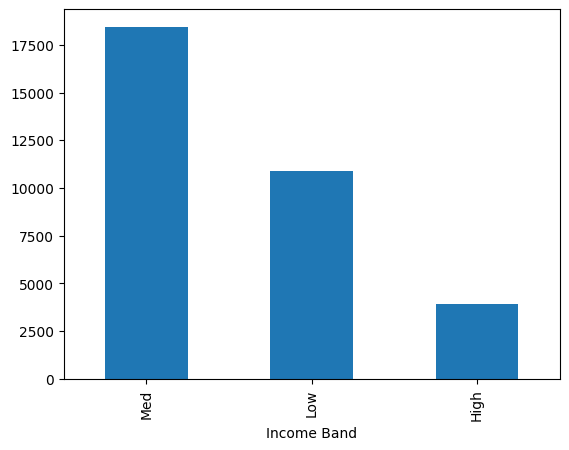

In [69]:
df['Income Band'].value_counts().plot(kind='bar')

## Examine the distribution of unique cataegories in categorical columns

In [72]:
# Value Counts for Categorical Columns

categorical_cols = df[[
    "brid",
    "genderid",
    "iaid",
    "amount_of_credit_cards",
    "nationality",
    "occupation",
    "fee_structure",
    "loyalty_classification",
    "properties_owned",
    "risk_weighting",

]].columns

for col in categorical_cols:
    print(f"Value Counts for '{col}':")
    display(df[col].value_counts())

Value Counts for 'brid':


,count
brid,
3.0,16021
1.0,6860
2.0,5207
4.0,5151


Value Counts for 'genderid':


,count
genderid,
2.0,17795
1.0,15444


Value Counts for 'iaid':


...

,count
loyalty_classification,
Jade,15803
Silver,8033
Gold,6077
Platinum,3326


Value Counts for 'properties_owned':


,count
properties_owned,
2.0,10214
1.0,8031
3.0,7618
0.0,7376


Value Counts for 'risk_weighting':


,count
risk_weighting,
2.0,14982
1.0,8941
3.0,4810
4.0,2979
5.0,1527


## Univariate Analysis

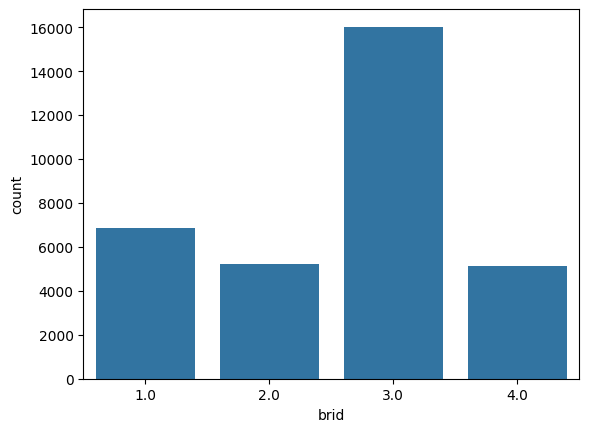

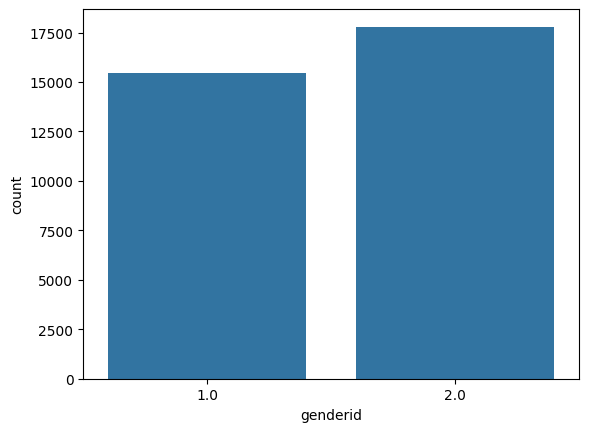

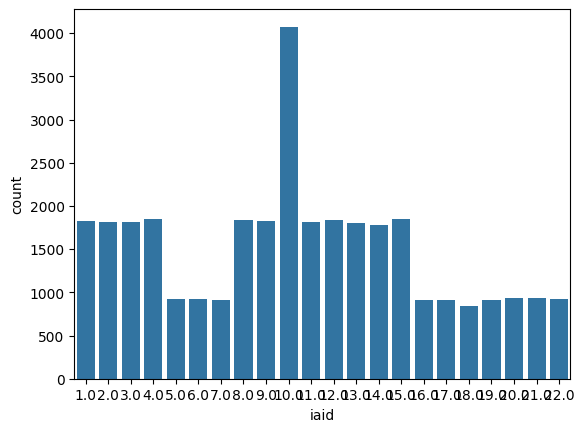

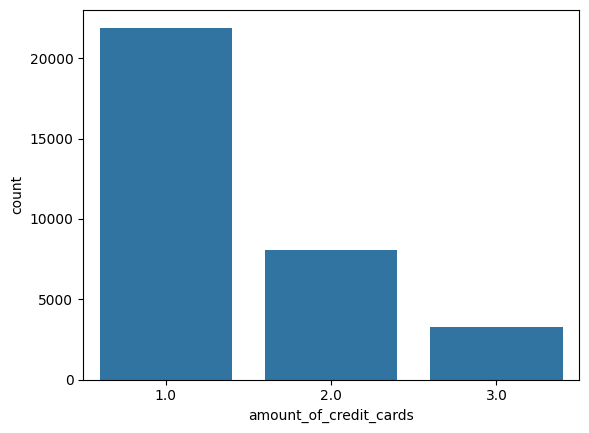

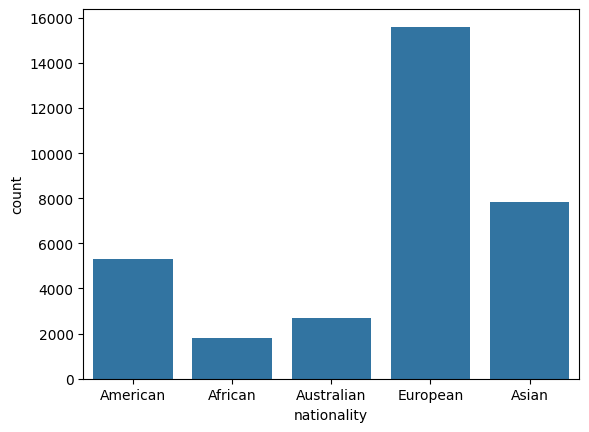

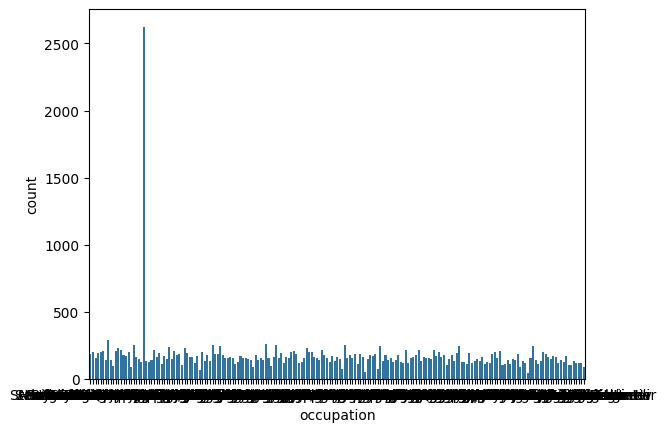

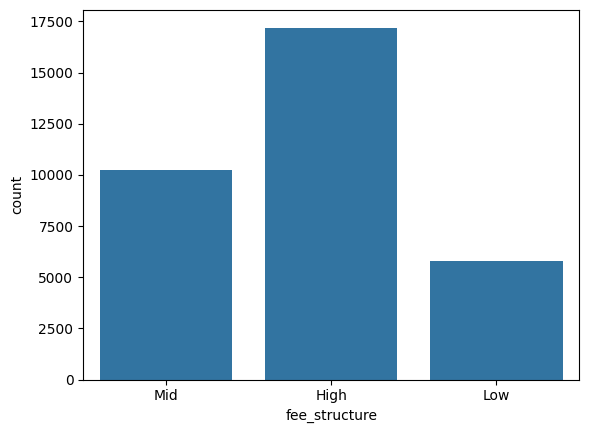

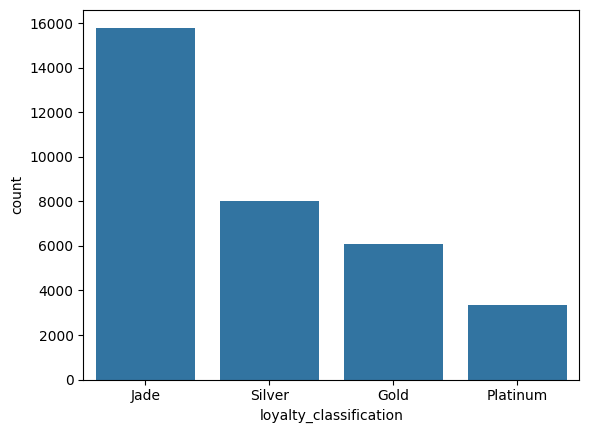

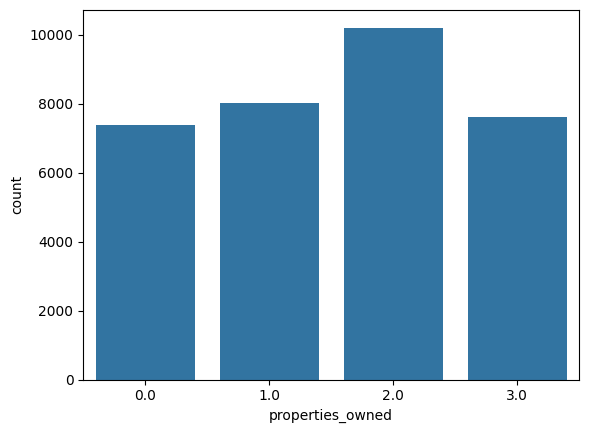

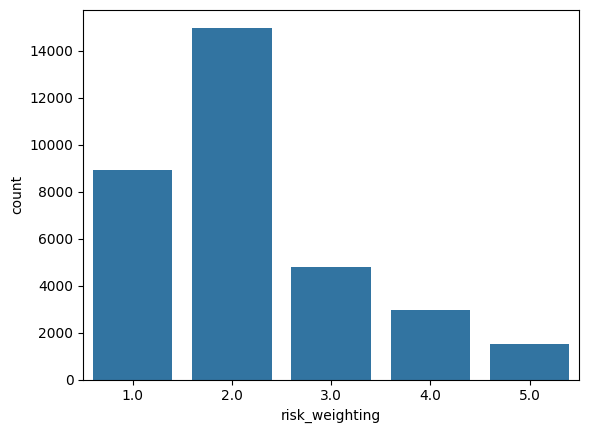

In [74]:
# Count Plot for Categorical Columns

for i, predictor in enumerate(df[[
    "brid",
    "genderid",
    "iaid",
    "amount_of_credit_cards",
    "nationality",
    "occupation",
    "fee_structure",
    "loyalty_classification",
    "properties_owned",
    "risk_weighting",

]].columns):

    plt.figure(i)

    sns.countplot(data=df, x=predictor)

## Bivariate Analysis

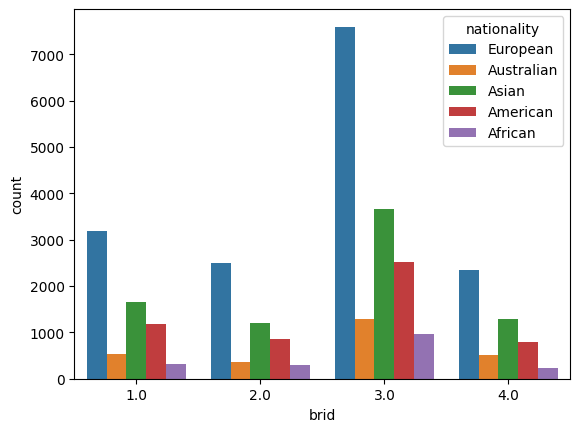

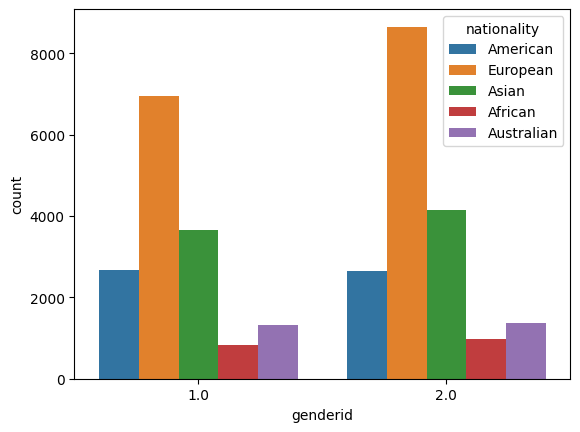

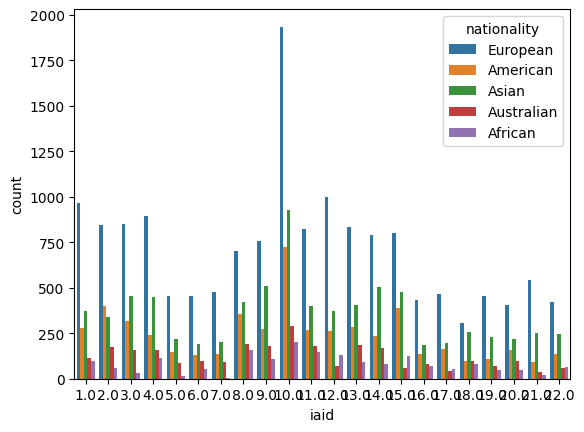

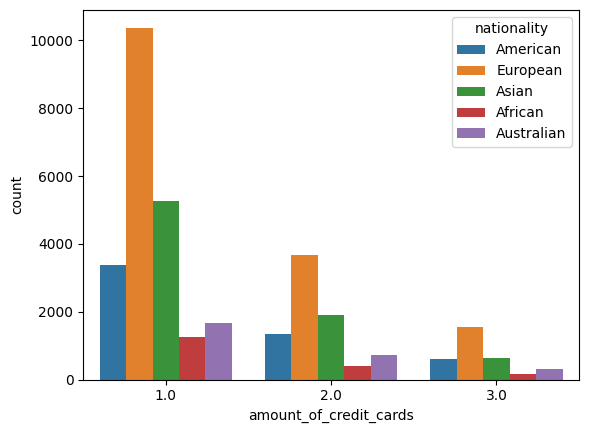

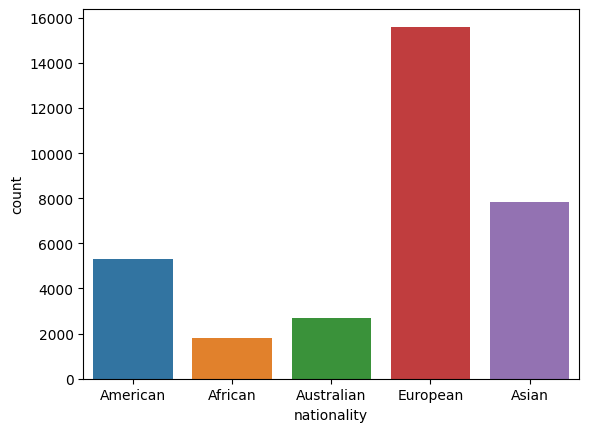

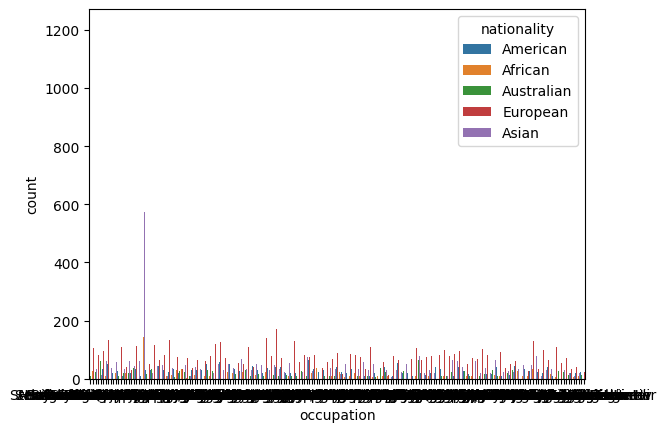

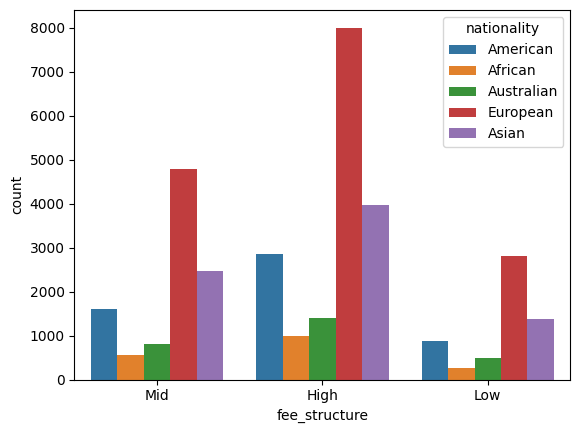

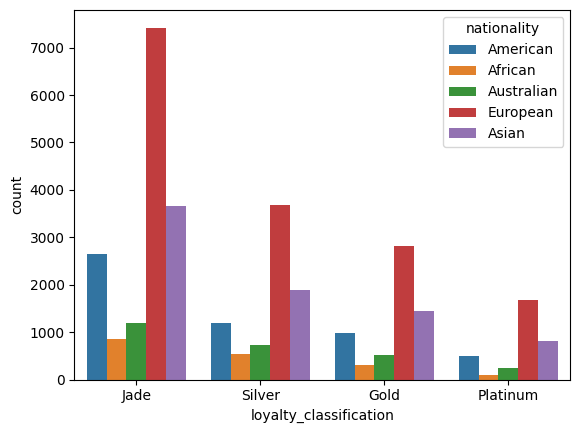

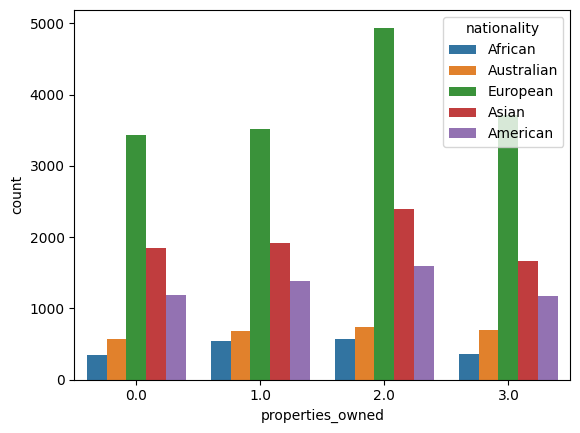

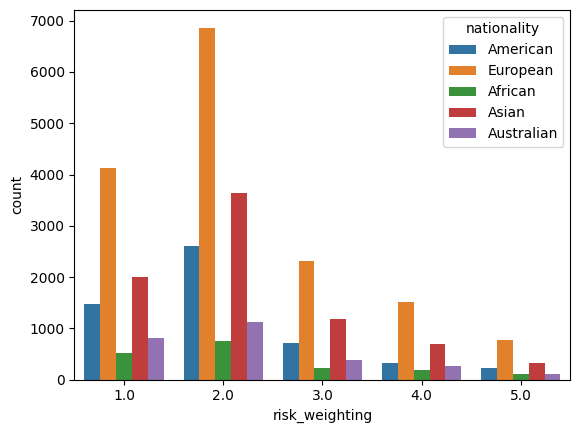

In [76]:
# Count Plot with Nationality as Hue

for i, predictor in enumerate(df[[
    "brid",
    "genderid",
    "iaid",
    "amount_of_credit_cards",
    "nationality",
    "occupation",
    "fee_structure",
    "loyalty_classification",
    "properties_owned",
    "risk_weighting",

]].columns):

    plt.figure(i)

    sns.countplot(
        data=df,
        x=predictor,
        hue='nationality'
    )

# HIstplot of value counts for different Occupation

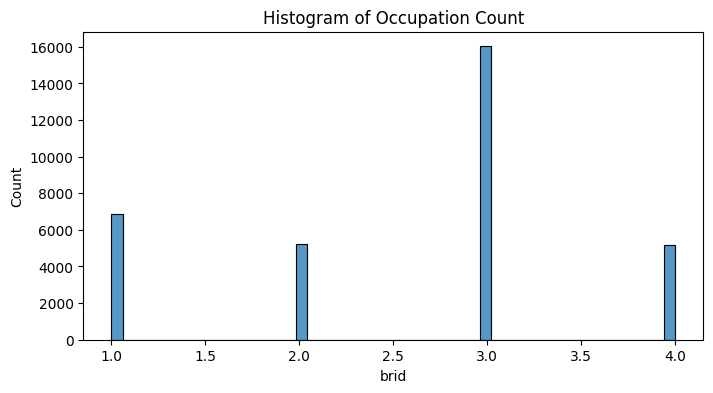

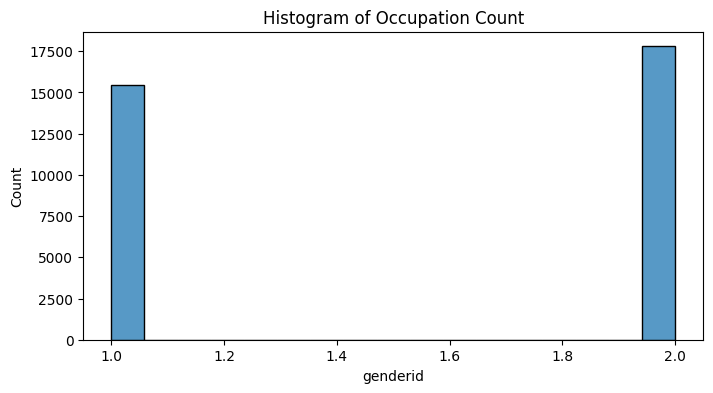

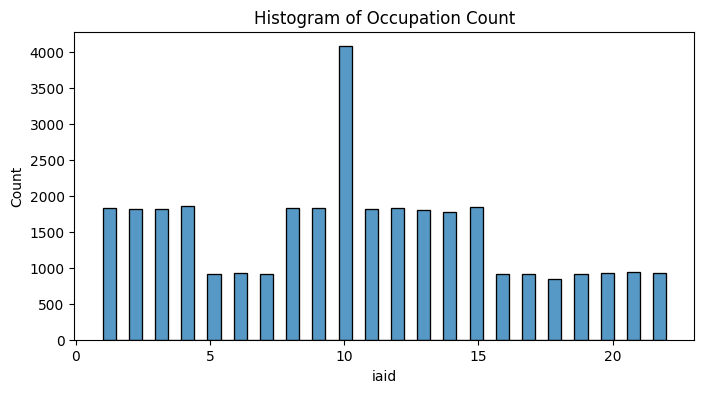

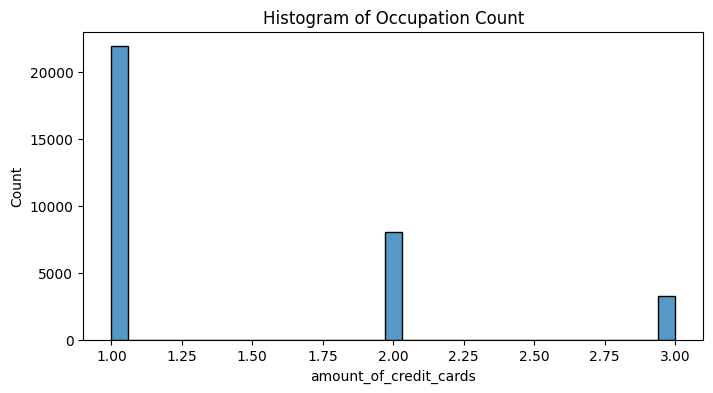

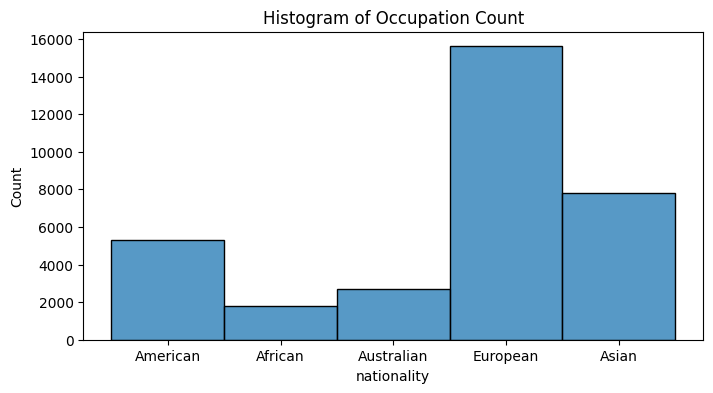

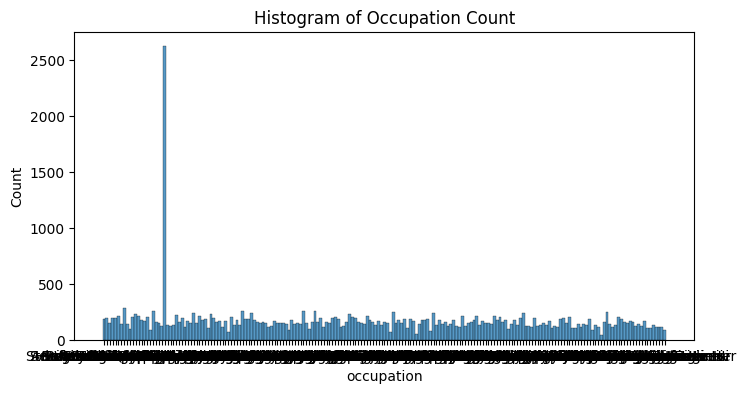

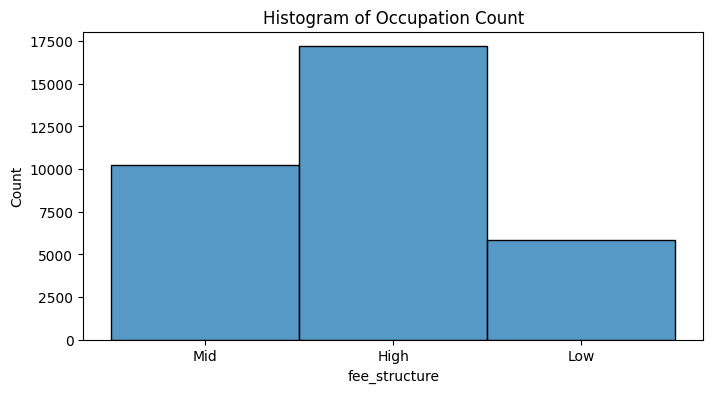

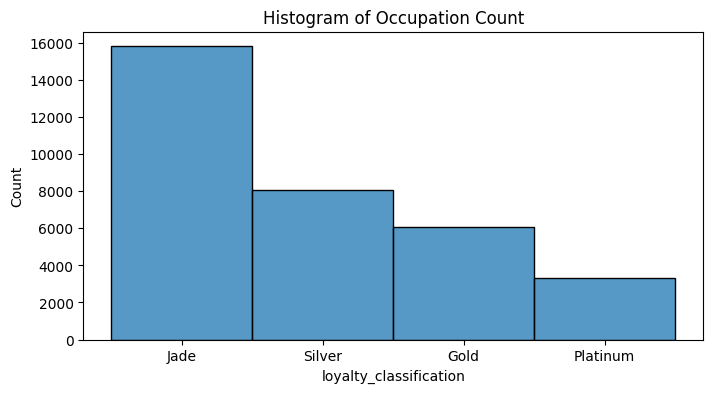

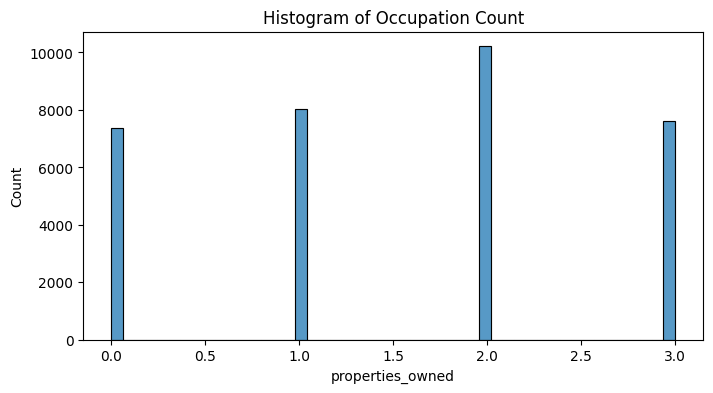

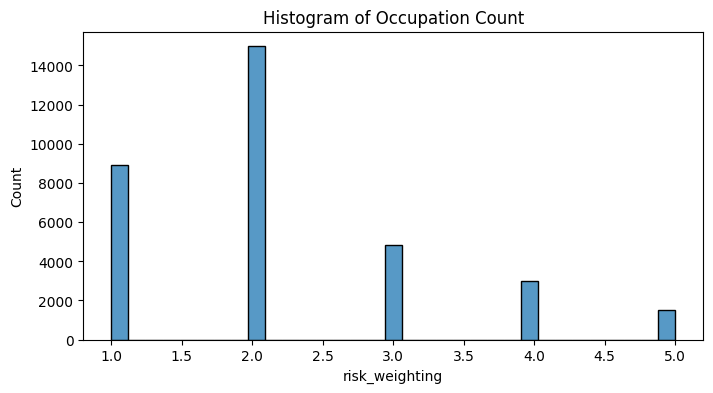

In [77]:


for col in categorical_cols:
  if col == "Occupation":
    continue
  plt.figure(figsize=(8,4))
  sns.histplot(df[col])
  plt.title('Histogram of Occupation Count')
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.show()

## Numerical Analysis



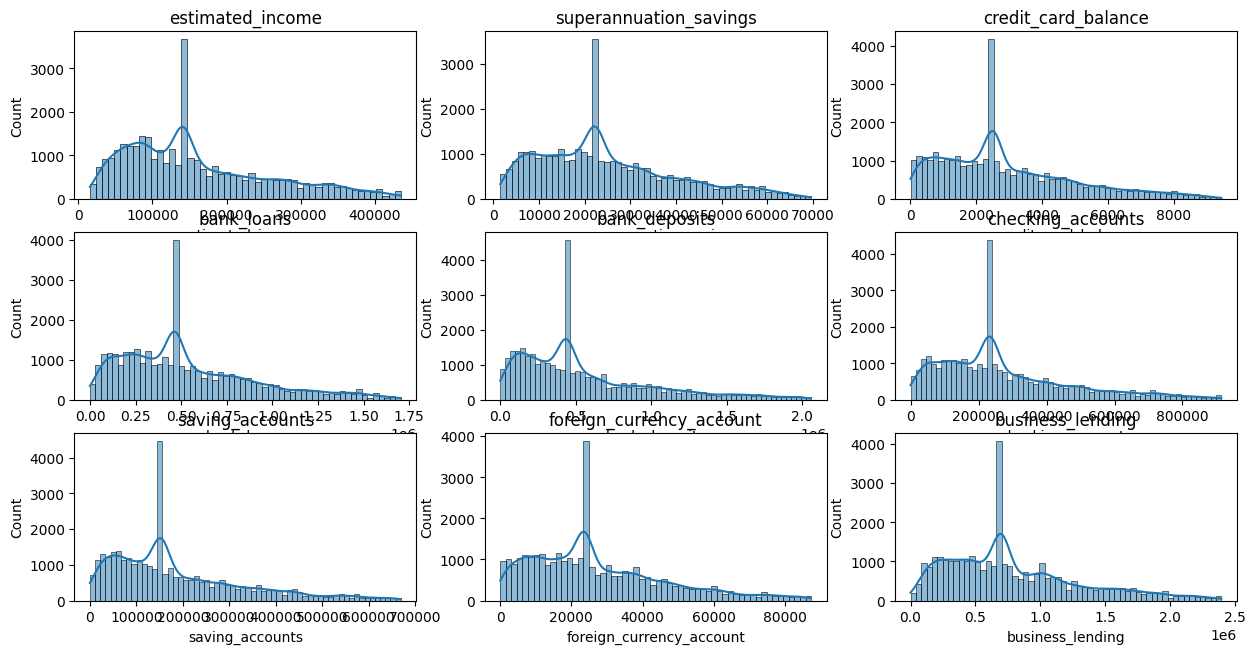

In [78]:
# Univariate Analysis of Numerical Columns

numerical_cols = [
    'estimated_income',
    'superannuation_savings',
    'credit_card_balance',
    'bank_loans',
    'bank_deposits',
    'checking_accounts',
    'saving_accounts',
    'foreign_currency_account',
    'business_lending'
]

# Univariate analysis and visualization

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols):

    plt.subplot(4,3,i+1)

    sns.histplot(df[col], kde=True)

    plt.title(col)

plt.show()

## Heatmaps

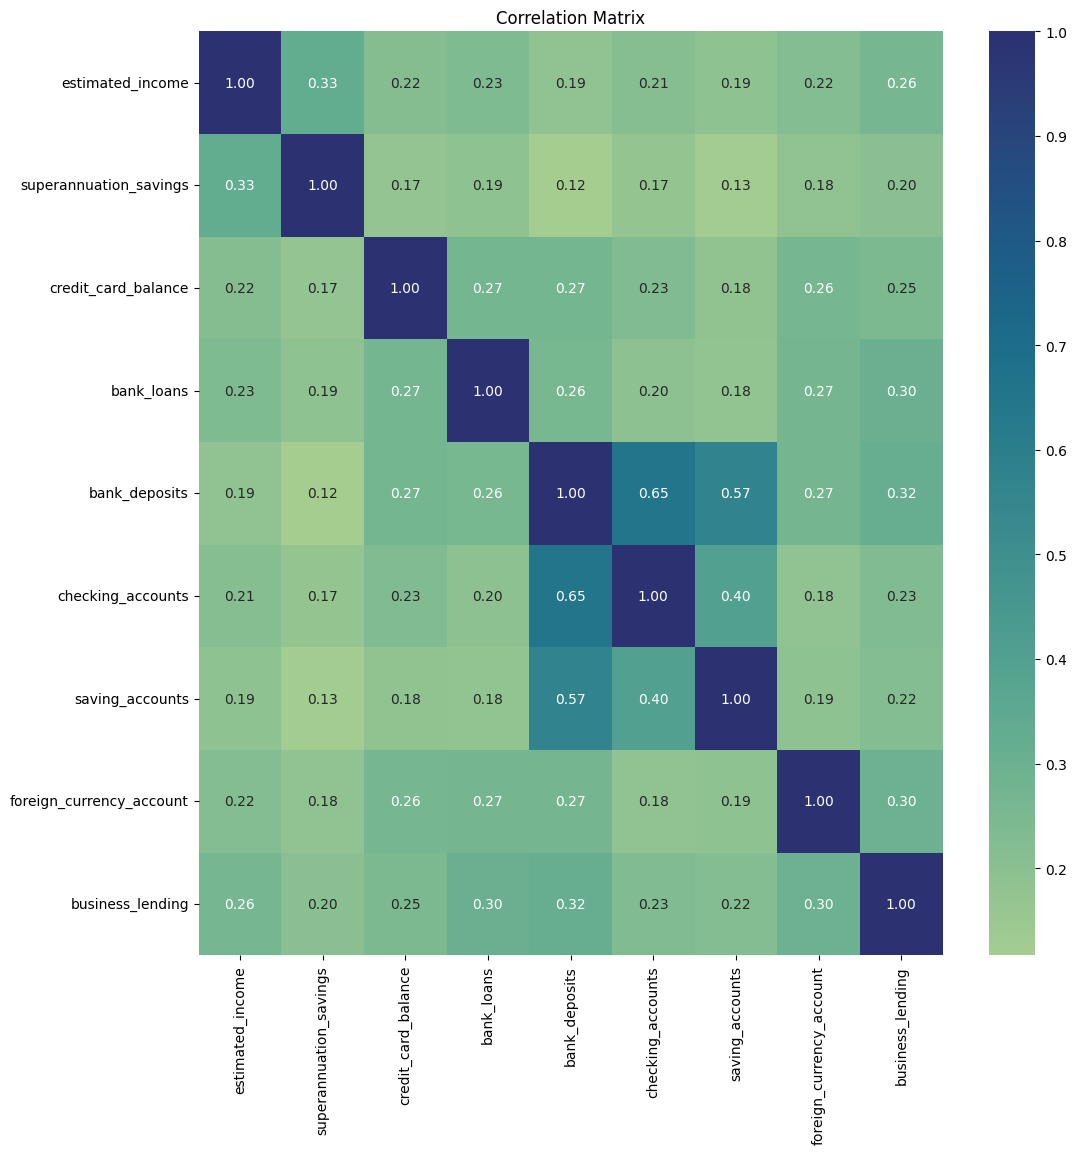

In [79]:
# Correlation Analysis of Numerical Columns

numerical_cols = [
    'estimated_income',
    'superannuation_savings',
    'credit_card_balance',
    'bank_loans',
    'bank_deposits',
    'checking_accounts',
    'saving_accounts',
    'foreign_currency_account',
    'business_lending'
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='crest',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [80]:
corr = df.corr(numeric_only=True)
print(corr)

                               age  location_id  estimated_income  \
age                       1.000000    -0.013351         -0.005998   
location_id              -0.013351     1.000000          0.002159   
estimated_income         -0.005998     0.002159          1.000000   
superannuation_savings   -0.026239     0.004854          0.333887   
amount_of_credit_cards    0.000224    -0.012763         -0.032600   
credit_card_balance      -0.005689     0.006793          0.217508   
bank_loans                0.000799    -0.010351          0.234310   
bank_deposits            -0.015833    -0.005855          0.185669   
checking_accounts        -0.009763    -0.002635          0.210745   
saving_accounts           0.014027    -0.002698          0.187878   
foreign_currency_account -0.017845     0.001172          0.220374   
business_lending          0.001338     0.008677          0.263060   
properties_owned         -0.001404    -0.020382         -0.008117   
risk_weighting           -0.007555

## Visualizing Correlation Heatmap



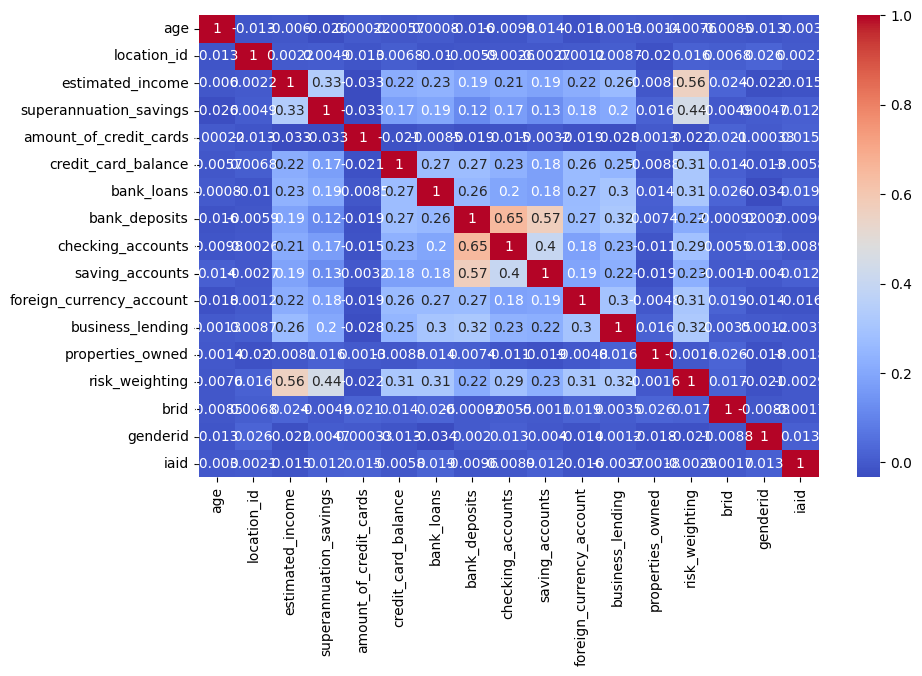

In [81]:


import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [82]:
df.shape

(33239, 26)

In [83]:
df.to_csv(
    "/content/Clean_Banking_Dataset.csv",
    index=False
)

In [84]:
from google.colab import files

files.download(
    "/content/Clean_Banking_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Save Python Code File

In [99]:


code = """
import pandas as pd

# Your code here
print("Hello")
"""

with open("cleaning_code.py", "w") as f:
    f.write(code)

In [100]:
from google.colab import files

files.download("cleaning_code.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>